In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import sqrt
from IPython.display import display, Markdown, HTML
from statsmodels.stats.power import TTestIndPower

# Slump-seed
np.random.seed(42)

# Ladda dataset med en relativ sökväg
file_path = 'data/health_study_dataset.csv'
df = pd.read_csv(file_path)

# --- Beskrivande analys ---

display(Markdown("## 1. Beskrivande analys"))

display(Markdown("### Dataöversikt"))
display(df.head())

display(Markdown("### Data information"))
df.info()

# Välja kolumner för deskriptiv statistik
columns_to_analyze = ["age", "weight", "height", "systolic_bp", "cholesterol"]

# Beräkna statistiken
descriptive_stats = df[columns_to_analyze].agg(["mean", "median", "min", "max"]).round(2)
display(Markdown("### Deskriptiv statistik"))
display(HTML(descriptive_stats.to_html()))

## 1. Beskrivande analys

### Dataöversikt

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


### Data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


### Deskriptiv statistik

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


## 2. Visualisering

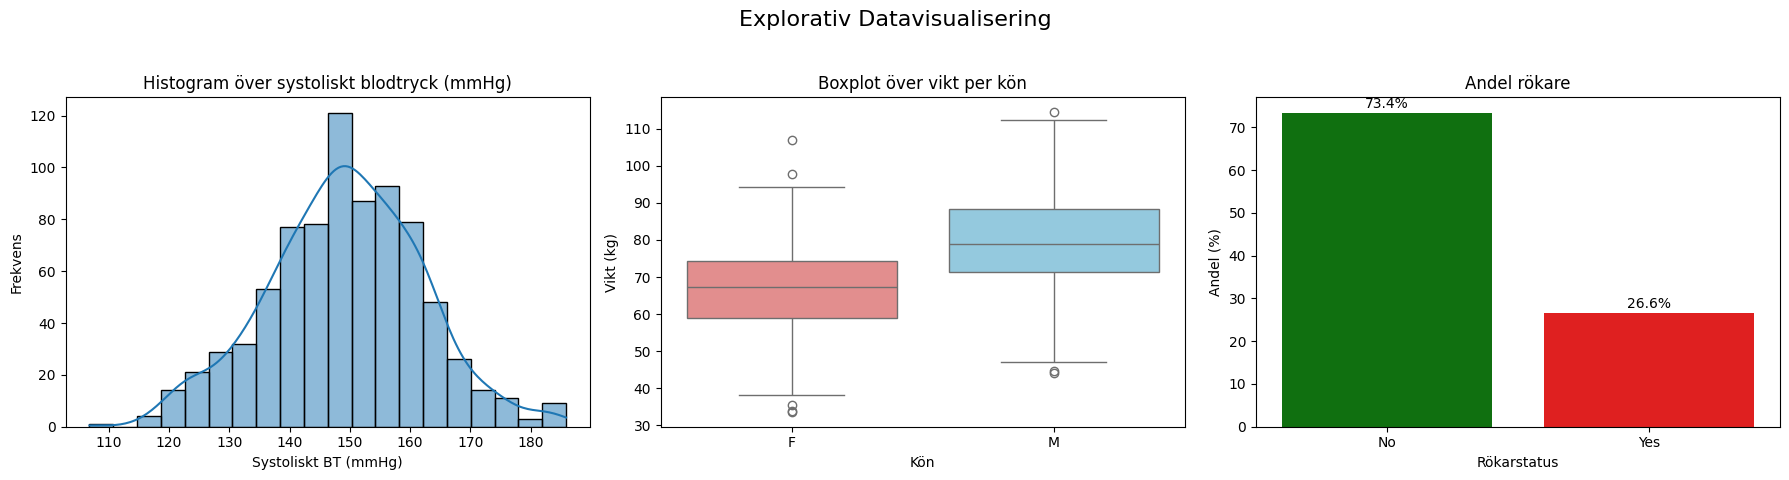

In [2]:
# --- Visualisering ---
display(Markdown("## 2. Visualisering"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('Explorativ Datavisualisering', fontsize=16)

# Graf 1: histogram över systoliskt blodtryck
sns.histplot(df['systolic_bp'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Histogram över systoliskt blodtryck (mmHg)')
axes[0].set_xlabel('Systoliskt BT (mmHg)')
axes[0].set_ylabel('Frekvens')

# Graf 2: boxplot över vikt per kön
sns.boxplot(x='sex', y='weight', hue='sex', data=df, ax=axes[1],
            palette={'M': 'skyblue', 'F': 'lightcoral'}, legend=False)
axes[1].set_title('Boxplot över vikt per kön')
axes[1].set_xlabel('Kön')
axes[1].set_ylabel('Vikt (kg)')

# Graf 3: stapeldiagram över andel rökare
smoker_proportions = df['smoker'].value_counts(normalize=True).mul(100).sort_index()
sns.barplot(x=smoker_proportions.index, y=smoker_proportions.values,
            hue=smoker_proportions.index, palette=['green', 'red'],
            ax=axes[2], legend=False)
axes[2].set_title('Andel rökare')
axes[2].set_xlabel('Rökarstatus')
axes[2].set_ylabel('Andel (%)')

# Lägg till procentetiketter
for i, val in enumerate(smoker_proportions.values):
    axes[2].text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
# --- Simulering ---
display(Markdown("## 3. Simulering kopplad till caset"))
display(Markdown("Den verkliga andelen sjuka beräknas och jämförs sedan med en simulering av 1000 slumpade personer."))

# Beräkna den faktiska andelen sjuka
actual_disease_rate = df["disease"].mean()

# Simulera 1000 personer (Bernoulli-försök)
num_simulations = 1000
simulated_outcomes = np.random.binomial(n=1, p=actual_disease_rate, size=num_simulations)

# Beräkna den simulerade andelen
simulated_disease_rate = simulated_outcomes.mean()

print(f"Verklig andel sjuka: {actual_disease_rate:.2%}")
print(f"Simulerad andel sjuka (1000 stickprov): {simulated_disease_rate:.2%}")
print(f"Skillnad (verklig - simulerad): {actual_disease_rate - simulated_disease_rate:.2%}")

## 3. Simulering kopplad till caset

Den verkliga andelen sjuka beräknas och jämförs sedan med en simulering av 1000 slumpade personer.

Verklig andel sjuka: 5.88%
Simulerad andel sjuka (1000 stickprov): 5.60%
Skillnad (verklig - simulerad): 0.27%


In [4]:
# --- Konfidensintervall ---
display(Markdown("## 4. Konfidensintervall"))
display(Markdown("Beräkna 95% konfidensintervall för medelvärdet av systolic_bp med normalapproximation och bootstrap-resampling."))

systolic_bp = df["systolic_bp"]
alpha = 0.05 #Signifikansnivå (5%) - motsvarar ett 95% konfidensintervall

# --- Metod 1: Normalapproximation (CLT) ---

def ci_mean_normal(data, confidence=0.95):
    x = np.asarray(data, dtype=float)
    mean_x = x.mean()
    s = x.std(ddof=1) # Stickprovsstandardavvikelse
    n = len(x)
    
    # Beräkna standardfel
    standard_error = s / sqrt(n) 
    
    # Hämta kritiskt Z-värde för konfidensnivån
    z_critical = stats.norm.ppf(1 - (1 - confidence) / 2)
    
    # Beräkna marginal of error (MOE)
    margin_of_error = z_critical * standard_error
    
    ci_lower = mean_x - margin_of_error
    ci_upper = mean_x + margin_of_error
    
    return (ci_lower, ci_upper, mean_x, s)

ci_norm_lower, ci_norm_upper, sample_mean, s = ci_mean_normal(systolic_bp.values, confidence=0.95)

print(f"95% KI (normalapproximation): ({ci_norm_lower:.2f}, {ci_norm_upper:.2f}) mmHg\n")


# --- Metod 2: Bootstrap resampling ---

def bootstrap_ci(data, num_replicates=10000, ci_level=0.95):
    np.random.seed(42)
    sample_means = [] # Lista för att lagra medelvärden från varje bootstrap-stickpro

# Kör bootstrap-simuleringar

    for _ in range(num_replicates):
        # Slumpmässigt stickprov med återläggning
        sample = np.random.choice(data, size=len(data), replace=True)
        # Beräkna och spara medelvärdet för stickprovet
        sample_means.append(np.mean(sample))

    # Beräkna gränser för konfidensintervallet
    lower_bound = (1 - ci_level) / 2 # Nedre gräns (2.5% vid 95% KI)
    upper_bound = 1 - (1 - ci_level) / 2 # Övre gräns (97.5% vid 95% KI)

    # Hämta percentiler från bootstrap-fördelningen
    ci_lower, ci_upper = np.percentile(sample_means,
                                       [lower_bound * 100, upper_bound * 100])
    return ci_lower, ci_upper

# Anropar funktionen med systoliskt blodtryck som input
ci_boot_lower, ci_boot_upper = bootstrap_ci(systolic_bp.values)

print(f"95% KI (bootstrap): ({ci_boot_lower:.2f}, {ci_boot_upper:.2f}) mmHg")

display(Markdown("""
### Jämförelse och slutsats

| Metod | 95% Konfidensintervall (KI) |
| :--- | :--- |
| **Normalapproximation (CLT)** | (148.29, 150.07) mmHg |
| **Bootstrap resampling** | (148.30, 150.07) mmHg |

Båda metoderna ger ett nästan identiskt 95% konfidensintervall för medelvärdet av systoliskt blodtryck. Vi är 95% säkra på att det sanna medelvärdet för det systoliska blodtrycket i populationen ligger mellan 148.29 mmHg och 150.07 mmHg. Överensstämmelsen mellan metoderna ger hög tillförlighet till resultatet.
"""))

## 4. Konfidensintervall

Beräkna 95% konfidensintervall för medelvärdet av systolic_bp med normalapproximation och bootstrap-resampling.

95% KI (normalapproximation): (148.29, 150.07) mmHg

95% KI (bootstrap): (148.30, 150.07) mmHg



### Jämförelse och slutsats

| Metod | 95% Konfidensintervall (KI) |
| :--- | :--- |
| **Normalapproximation (CLT)** | (148.29, 150.07) mmHg |
| **Bootstrap resampling** | (148.30, 150.07) mmHg |

Båda metoderna ger ett nästan identiskt 95% konfidensintervall för medelvärdet av systoliskt blodtryck. Vi är 95% säkra på att det sanna medelvärdet för det systoliska blodtrycket i populationen ligger mellan 148.29 mmHg och 150.07 mmHg. Överensstämmelsen mellan metoderna ger hög tillförlighet till resultatet.


## 5. Hypotesprövning


Vi testar hypotesen att rökare har högre blodtryck än icke-rökare med två metoder:
1.  **Welch's t-test** (parametriskt)
2.  **Permutationstest** (icke-parametriskt)


#### Analys av extremvärden


| Grupp | Original medelvärde | Klippt medelvärde (1-99%) |
| :--- | :--- | :--- |
| **Rökare** | 149.52 mmHg | 149.19 mmHg |
| **Icke-rökare** | 149.05 mmHg | 149.15 mmHg |


*Skillnaden mellan original och klippt data är minimal, vilket tyder på att outliers inte snedvrider analysen.*

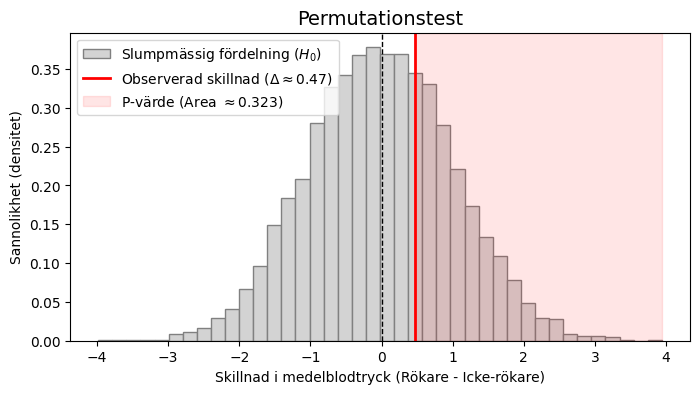

### Resultatöversikt


| Metod | Test-statistik | P-värde | Slutsats ($\, \alpha=0.05 \,$) |
| :--- | :--- | :--- | :--- |
| **Welch's t-test** | $t = 0.4503$ | $0.3264$ | **Ej signifikant** (behåll $H_0$) |
| **Permutationstest** | $\Delta = 0.4719$ | $0.3231$ | **Ej signifikant** (behåll $H_0$) |


### Resultatförklaring


Båda metoderna ger samstämmiga resultat. Det observerade P-värdet är betydligt högre än signifikansnivån $\alpha=0.05$.

Vi **misslyckas därför med att förkasta nollhypotesen**. Det finns inte tillräckligt med bevis för att påstå att rökare har högre blodtryck än icke-rökare i denna population. Den lilla skillnad vi ser ($\Delta \approx 0.47$ mmHg) ligger väl inom ramen för vad som kan förväntas av ren slump.


In [5]:
# --- Hypotesprövning ---

# Filtera ut data
bp_smoker = df[df["smoker"] == "Yes"]["systolic_bp"]
bp_non_smoker = df[df["smoker"] == "No"]["systolic_bp"]
A = bp_non_smoker.values # Icke-rökare
B = bp_smoker.values     # Rökare
alpha = 0.05 

display(Markdown("## 5. Hypotesprövning"))
display(Markdown("""
Vi testar hypotesen att rökare har högre blodtryck än icke-rökare med två metoder:
1.  **Welch's t-test** (parametriskt)
2.  **Permutationstest** (icke-parametriskt)
"""))

# --- 1. Analys av extremvärden (outliers) ---
# Jämför medelvärden före och efter att vi klippt bort de mest extrema 1% för att se om outliers driver resultatet.
low_q, high_q = df["systolic_bp"].quantile([0.01, 0.99])
clipped_df = df[(df["systolic_bp"] >= low_q) & (df["systolic_bp"] <= high_q)].copy()

A_clipped = clipped_df.loc[clipped_df.smoker == "No", "systolic_bp"].values
B_clipped = clipped_df.loc[clipped_df.smoker == "Yes", "systolic_bp"].values


outlier_table = f"""
| Grupp | Original medelvärde | Klippt medelvärde (1-99%) |
| :--- | :--- | :--- |
| **Rökare** | {B.mean():.2f} mmHg | {B_clipped.mean():.2f} mmHg |
| **Icke-rökare** | {A.mean():.2f} mmHg | {A_clipped.mean():.2f} mmHg |
"""
display(Markdown("#### Analys av extremvärden"))
display(Markdown(outlier_table))
display(Markdown("*Skillnaden mellan original och klippt data är minimal, vilket tyder på att outliers inte snedvrider analysen.*"))


# --- 2. Beräkningar ---
# Welch's T-test
t_stat, p_value_two_sided = stats.ttest_ind(B, A, equal_var=False)
p_value_one_sided = p_value_two_sided / 2 if t_stat > 0 else 1.0

# Permutationstest
all_vals = np.concatenate([A, B])
nA, nB = len(A), len(B)
obs_diff = B.mean() - A.mean()

n_perm = 10_000
perm_diffs = np.empty(n_perm)
np.random.seed(42) # Sätt seed för reproducerbarhet av permutationen

for i in range(n_perm):
    perm = np.random.permutation(all_vals)
    perm_diffs[i] = perm[nA:].mean() - perm[:nA].mean() # Rökare (B) - Icke-rökare (A)

p_perm = np.mean(perm_diffs >= obs_diff)


# --- 3. Visualisering ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_diffs, bins=40, density=True, color='lightgray', edgecolor='gray', label="Slumpmässig fördelning ($H_0$)")
ax.axvline(obs_diff, color="red", linestyle="-", linewidth=2, label=f"Observerad skillnad ($\Delta \\approx {obs_diff:.2f}$)")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
# Markera p-värdes-området
ax.axvspan(obs_diff, perm_diffs.max(), color='red', alpha=0.1, label=f"P-värde (Area $\\approx {p_perm:.3f}$)")

ax.set_title("Permutationstest", fontsize=14)
ax.set_xlabel("Skillnad i medelblodtryck (Rökare - Icke-rökare)")
ax.set_ylabel("Sannolikhet (densitet)")
ax.legend()
plt.savefig('results/permutation_test.png')
plt.show()


# --- 4. Slutsats ---
display(Markdown("### Resultatöversikt"))

final_table = f"""
| Metod | Test-statistik | P-värde | Slutsats ($\, \\alpha={alpha} \,$) |
| :--- | :--- | :--- | :--- |
| **Welch's t-test** | $t = {t_stat:.4f}$ | ${p_value_one_sided:.4f}$ | **Ej signifikant** (behåll $H_0$) |
| **Permutationstest** | $\Delta = {obs_diff:.4f}$ | ${p_perm:.4f}$ | **Ej signifikant** (behåll $H_0$) |
"""
display(Markdown(final_table))

display(Markdown("### Resultatförklaring"))
display(Markdown(f"""
Båda metoderna ger samstämmiga resultat. Det observerade P-värdet är betydligt högre än signifikansnivån $\\alpha={alpha}$.

Vi **misslyckas därför med att förkasta nollhypotesen**. Det finns inte tillräckligt med bevis för att påstå att rökare har högre blodtryck än icke-rökare i denna population. Den lilla skillnad vi ser ($\Delta \\approx 0.47$ mmHg) ligger väl inom ramen för vad som kan förväntas av ren slump.
"""))

## 6. Power-simulering för hypotesprövning


Denna analys beräknar den statistiska kraften (power) analytiskt. Vi undersöker hur säkert vårt t-test är genom att **anta** att en sann skillnad på 2.5 mmHg existerar mellan grupperna.


--- Power-analys ---
Antagen sann skillnad: 2.5 mmHg
Cohen's d (standardiserad effektstorlek): 0.1954
Uppskattad statistisk power: 0.7870


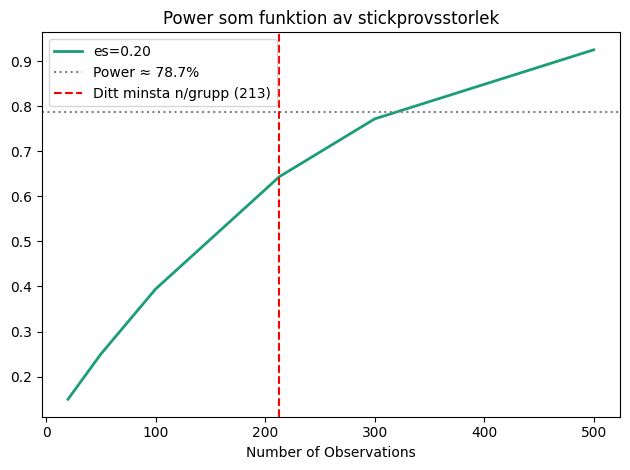


Slutsats: Om den sanna skillnaden vore 2.5 mmHg, skulle vårt test ha 78.7% chans att upptäcka den.


In [6]:
# --- Power-simulering ---

display(Markdown("## 6. Power-simulering för hypotesprövning"))
display(Markdown("""
Denna analys beräknar den statistiska kraften (power) analytiskt. Vi undersöker hur säkert vårt t-test är genom att **anta** att en sann skillnad på 2.5 mmHg existerar mellan grupperna.
"""))

# Parametrar
assumed_true_diff = 2.5 
alpha = 0.05
power_target = 0.80 

# Parametrar härledda från verklig data
N_smoker = len(bp_smoker)
N_non_smoker = len(bp_non_smoker)
Pooled_Std = systolic_bp.std() 

# Beräkna Cohen's d
effect_size_d = assumed_true_diff / Pooled_Std 

# Beräkna den analytiska power-nivån
analytic_power = TTestIndPower().power(
    effect_size=effect_size_d,
    nobs1=N_smoker,
    alpha=alpha,
    ratio=N_non_smoker / N_smoker,
    alternative="larger" 
)

print("--- Power-analys ---")
print(f"Antagen sann skillnad: {assumed_true_diff} mmHg")
print(f"Cohen's d (standardiserad effektstorlek): {effect_size_d:.4f}")
print(f"Uppskattad statistisk power: {analytic_power:.4f}")

# --- Visualisering ---

fig = TTestIndPower().plot_power(
    dep_var='nobs', 
    nobs=np.array([20, 50, 100, N_smoker, 300, 500]), 
    effect_size=[effect_size_d],
    alpha=alpha,
    title='Power som funktion av stickprovsstorlek',
    alternative='larger'
)

ax = fig.gca()
ax.axhline(analytic_power, color='gray', linestyle=':', label=f"Power ≈ {analytic_power:.1%}")
ax.axvline(N_smoker, color='red', linestyle='--', label=f"Ditt minsta n/grupp ({N_smoker})")
ax.legend()
plt.tight_layout()
plt.savefig('results/power_simulation.png')
plt.show()

print(f"\nSlutsats: Om den sanna skillnaden vore {assumed_true_diff} mmHg, skulle vårt test ha {analytic_power:.1%} chans att upptäcka den.")

In [7]:
# --- Metodval och källhänvisning ---

display(Markdown("## 7. Metodval och källhänvisning"))
display(Markdown("""


### 1. Konfidensintervall: parametrisk och icke-parametrisk
**Metod:**
Konfidensintervallet beräknades med två metoder: **normalapproximation** (baserad på Central Limit Theorem) och **bootstrap** (Percentile method).

**Motivering:**
Eftersom stickprovet är stort ($N=800$) gäller Centrala Gränsvärdessatsen (CLT), vilket gör normalapproximationen giltig. För fördjupning användes även bootstrap som en icke-parametrisk verifiering. Eftersom bootstrap-metoden inte gör några antaganden om datans underliggande fördelning, och resultatet överensstämde nästan exakt med normalapproximationen, kan vi vara mycket trygga i resultatet.

**Källor:**
* **NumPy Documentation:** [`numpy.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) 
* **Kursmaterial:** Joakims YouTube videor
                 
### 2. Hypotesprövning: parametrisk och icke-parametrisk metod
**Metod:**
För att testa nollhypotesen ($H_0$: ingen skillnad i blodtryck) användes två metoder:
1.  **Welch’s t-test** (parametrisk metod)
2.  **Permutationstest** (icke-parametrisk metod med 10 000 simuleringar)

**Motivering:**
* **Welch's t-test:** Valdes istället för standard t-test eftersom stickprovsstorlekarna är olika och vi inte kan anta lika varians (homoscedasticitet).
* **Permutationstest:** Valdes som en valideringsmetod för fördjupning. Eftersom permutationstestet inte gör några antaganden om normalfördelning, fungerar det som en robust kontroll av t-testets resultat. Att båda metoderna gav snarlika P-värden stärker tillförlitligheten i slutsatsen.

**Källor:**
* **SciPy Documentation:** [`scipy.stats.ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) (för Welch's test)
* **NumPy Documentation:** [`numpy.random.permutation`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html) (användes för att bygga permutationstestet)
* **Kursmaterial:** Joakims YouTube videor

### 3. Power-simulering och permutationstest
**Metod:**
En **power-analys** genomfördes med `statsmodels`, samt ett **permutationstest**.

**Motivering:**
Eftersom resultatet från t-testet inte var signifikant ($p > 0.05$), var det kritiskt att undersöka testets styrka (power). Analysen visade en power på ca 79% för att upptäcka en skillnad på 2.5 mmHg. Detta innebär att risken för ett Typ II-fel (att missa en verklig effekt) var acceptabelt låg. Tillsammans med permutationstestet (som gav samma p-värde som t-testet) bekräftar detta att slutsatsen att **inte** förkasta $H_0$ är välgrundad och inte beror på brister i testmetodiken.

**Källor:**
* **Statsmodels Documentation:** [`statsmodels.stats.power.TTestIndPower`](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.html)
* **Kursmaterial:** Joakims YouTube videor
"""))

## 7. Metodval och källhänvisning




### 1. Konfidensintervall: parametrisk och icke-parametrisk
**Metod:**
Konfidensintervallet beräknades med två metoder: **normalapproximation** (baserad på Central Limit Theorem) och **bootstrap** (Percentile method).

**Motivering:**
Eftersom stickprovet är stort ($N=800$) gäller Centrala Gränsvärdessatsen (CLT), vilket gör normalapproximationen giltig. För fördjupning användes även bootstrap som en icke-parametrisk verifiering. Eftersom bootstrap-metoden inte gör några antaganden om datans underliggande fördelning, och resultatet överensstämde nästan exakt med normalapproximationen, kan vi vara mycket trygga i resultatet.

**Källor:**
* **NumPy Documentation:** [`numpy.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) 
* **Kursmaterial:** Joakims YouTube videor

### 2. Hypotesprövning: parametrisk och icke-parametrisk metod
**Metod:**
För att testa nollhypotesen ($H_0$: ingen skillnad i blodtryck) användes två metoder:
1.  **Welch’s t-test** (parametrisk metod)
2.  **Permutationstest** (icke-parametrisk metod med 10 000 simuleringar)

**Motivering:**
* **Welch's t-test:** Valdes istället för standard t-test eftersom stickprovsstorlekarna är olika och vi inte kan anta lika varians (homoscedasticitet).
* **Permutationstest:** Valdes som en valideringsmetod för fördjupning. Eftersom permutationstestet inte gör några antaganden om normalfördelning, fungerar det som en robust kontroll av t-testets resultat. Att båda metoderna gav snarlika P-värden stärker tillförlitligheten i slutsatsen.

**Källor:**
* **SciPy Documentation:** [`scipy.stats.ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) (för Welch's test)
* **NumPy Documentation:** [`numpy.random.permutation`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html) (användes för att bygga permutationstestet)
* **Kursmaterial:** Joakims YouTube videor

### 3. Power-simulering och permutationstest
**Metod:**
En **power-analys** genomfördes med `statsmodels`, samt ett **permutationstest**.

**Motivering:**
Eftersom resultatet från t-testet inte var signifikant ($p > 0.05$), var det kritiskt att undersöka testets styrka (power). Analysen visade en power på ca 79% för att upptäcka en skillnad på 2.5 mmHg. Detta innebär att risken för ett Typ II-fel (att missa en verklig effekt) var acceptabelt låg. Tillsammans med permutationstestet (som gav samma p-värde som t-testet) bekräftar detta att slutsatsen att **inte** förkasta $H_0$ är välgrundad och inte beror på brister i testmetodiken.

**Källor:**
* **Statsmodels Documentation:** [`statsmodels.stats.power.TTestIndPower`](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.html)
* **Kursmaterial:** Joakims YouTube videor
